| STT | Tên | MSSV | Đánh giá tiến độ |
|-----|-----|------|------------------|
| 1   |     |      |                  |
| 2   |     |      |                  |
| 3   |     |      |                  |
| 4   |     |      |                  |
| 5   |     |      |                  |
| 6   |     |      |                  |
| 7   |     |      |                  |

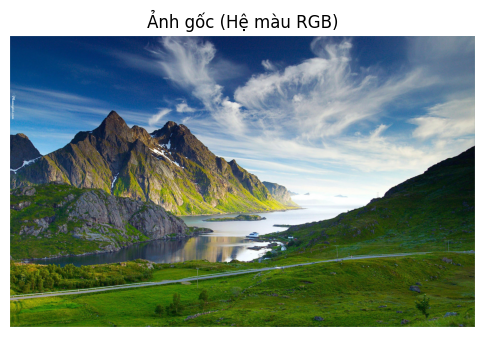

Đã lưu ảnh tại: images/output/out.png


In [1]:
import cv2
import matplotlib.pyplot as plt

input_image_path = 'images/input/in.jpg'
output_image_path = 'images/output/out.png'

original_bgr_image = cv2.imread(input_image_path)

# Kiểm tra
if original_bgr_image is None:
    print("Không tìm thấy ảnh! Vui lòng kiểm tra lại đường dẫn.")
else:
    # Vì Matplotlib hiển thị ảnh theo chuẩn RGB, nên ta phải chuyển từ BGR -> RGB
    original_rgb_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6)) # Thiết lập kích thước khung hình hiển thị
    plt.imshow(original_rgb_image)
    plt.title("Ảnh gốc (Hệ màu RGB)") # Đặt tiêu đề cho hình
    plt.axis('off') # Tắt hiển thị trục tọa độ (x, y)
    plt.show()

    # cv2.imwrite sử dụng định dạng BGR, nên ta dùng biến original_bgr_image
    cv2.imwrite(output_image_path, original_bgr_image)
    print(f"Đã lưu ảnh tại: {output_image_path}")

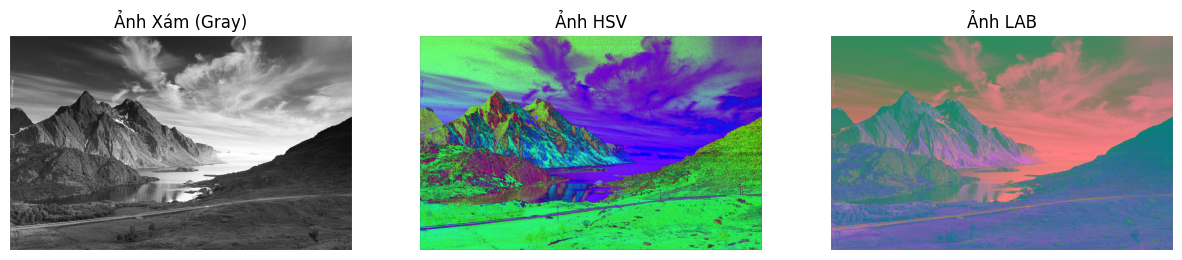

In [2]:
# 1. Chuyển ảnh BGR sang các không gian màu khác nhau

# Ảnh xám (Gray): Chỉ giữ lại độ sáng (Luminance), giảm bớt dữ liệu để xử lý nhanh
gray_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2GRAY)

# Ảnh HSV: Tách biệt sắc thái (Hue), độ bão hòa (Saturation) và giá trị độ sáng (Value)
# Thường được dùng để lọc màu hoặc xác định vùng màu sắc
hsv_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2HSV)

# Ảnh LAB: Chứa kênh độ sáng (L) và hai kênh màu (A, B)
# Gần gũi với mắt người nhất về độ tương đồng màu sắc
lab_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2LAB)

# 2. Hiển thị song song các ảnh
# Tạo 1 hàng gồm 3 cột để so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Hiển thị ảnh xám: Lưu ý phải dùng cmap='gray' để Matplotlib hiểu là ảnh đơn sắc
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Ảnh Xám (Gray)')
axes[0].axis('off')

axes[1].imshow(hsv_image)
axes[1].set_title('Ảnh HSV')
axes[1].axis('off')

axes[2].imshow(lab_image)
axes[2].set_title('Ảnh LAB')
axes[2].axis('off')

plt.show()

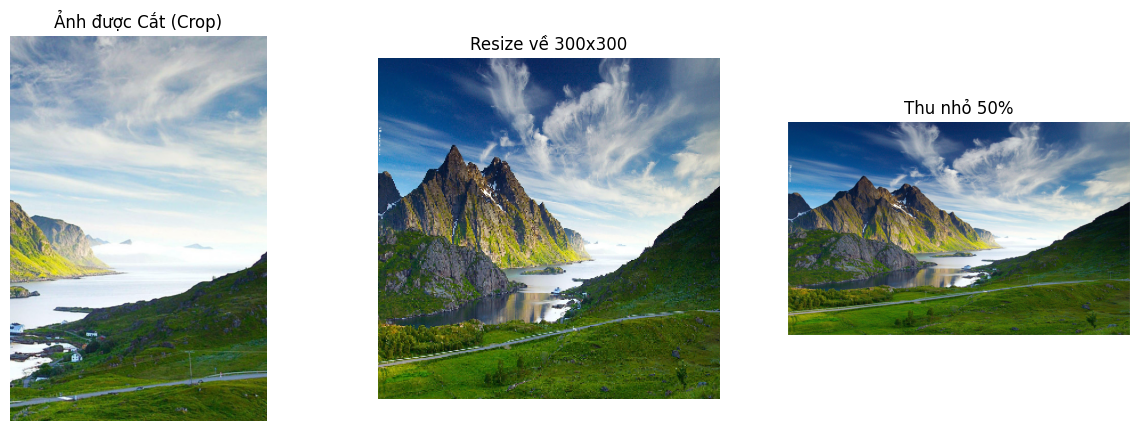

In [3]:
# 1. Cắt ảnh (Cropping)
# Ảnh là một ma trận, ta có thể dùng kỹ thuật slicing: [dòng_bắt_đầu:dòng_kết_thúc, cột_bắt_đầu:cột_kết_thúc]
y_start, y_end = 500, 2000 # Xác định vị trí dọc (y)
x_start, x_end = 2000, 3000 # Xác định vị trí ngang (x)
cropped_image = original_rgb_image[y_start:y_end, x_start:x_end] 

# 2. Thay đổi kích thước (Resizing)

# Cách 1: Đưa về một kích thước cố định (chiều rộng, chiều cao)
target_width = 300
target_height = 300
resized_300x300_image = cv2.resize(original_rgb_image, (target_width, target_height))

# Cách 2: Thu nhỏ theo tỷ lệ phần trăm (ví dụ: thu nhỏ còn 50%)
scale_percent = 0.5 
# fx và fy là hệ số tỉ lệ cho trục ngang (x) và dọc (y)
resized_half_image = cv2.resize(original_rgb_image, None, fx=scale_percent, fy=scale_percent, interpolation=cv2.INTER_LINEAR)

# Hiển thị kết quả so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cropped_image)
axes[0].set_title('Ảnh được Cắt (Crop)')
axes[1].imshow(resized_300x300_image)
axes[1].set_title('Resize về 300x300')
axes[2].imshow(resized_half_image)
axes[2].set_title('Thu nhỏ 50%')

for ax in axes:
    ax.axis('off')
plt.show()

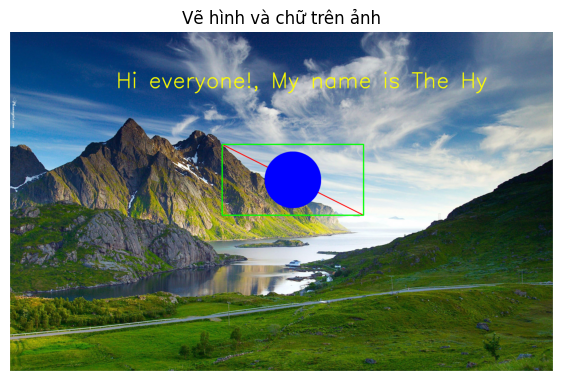

In [4]:
# 1. Tạo bản copy để thực hiện vẽ và ghi
image_for_drawing = original_rgb_image.copy()
# 2. Định nghĩa màu sắc (Hệ RGB: R=Red, G=Green, B=Blue)
red_color = (255, 0, 0)
green_color = (0, 255, 0)
blue_color = (0, 0, 255)
yellow_color = (255, 255, 0)

# 3. Vẽ ĐƯỜNG THẲNG (Line)
# cv2.line(ảnh, điểm_đầu, điểm_cuối, màu, độ_dày)
line_start_point = (1500, 800) # (x, y)
line_end_point = (2500, 1300)
line_thickness = 5
cv2.line(image_for_drawing, line_start_point, line_end_point, red_color, line_thickness)

# 4. Vẽ HÌNH CHỮ NHẬT (Rectangle)
# cv2.rectangle(ảnh, điểm_góc_trên_trái, điểm_góc_dưới_phải, màu, độ_dày)
rect_top_left = (1500, 800)
rect_bottom_right = (2500, 1300)
rect_thickness = 8
cv2.rectangle(image_for_drawing, rect_top_left, rect_bottom_right, green_color, rect_thickness)

# 5. Vẽ HÌNH TRÒN (Circle)
# cv2.circle(ảnh, tâm, bán_kính, màu, độ_dày)
circle_center = (2000, 1050)
circle_radius = 200
fill_shape = -1 # Sử dụng giá trị -1 để tô kín toàn bộ hình (solid fill)
cv2.circle(image_for_drawing, circle_center, circle_radius, blue_color, fill_shape)

# 6. THÊM VĂN BẢN (Text)
# cv2.putText(ảnh, nội_dung, vị_trí_bắt_đầu, kiểu_chữ, cỡ_chữ, màu, độ_dày)
text_content = "Hi everyone!, My name is The Hy"
text_bottom_left = (750, 400)
font_type = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 5
text_thickness = 8
cv2.putText(image_for_drawing, text_content, text_bottom_left, font_type, font_scale, yellow_color, text_thickness)

# 7. HIỂN THỊ KẾT QUẢ CUỐI CÙNG
plt.figure(figsize=(7, 7))
plt.imshow(image_for_drawing)
plt.title("Vẽ hình và chữ trên ảnh")
plt.axis('off')
plt.show()